In [75]:
import glob
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

path = "../results/20260224_125410_skew"
FILES = glob.glob(path+"/consumer/consumer-sts-*_metrics/consumer_metrics_run-*_consumer-sts-*.csv")  


if not FILES:
    raise FileNotFoundError("No CSV files found. Update FILES glob pattern.")

In [76]:
from pathlib import Path
run_id = Path(path).resolve().name

print(run_id)


20260224_125410_skew


In [77]:

def pod_from_name(path: str) -> str:
    m = re.search(r"(consumer-sts-\d+)", os.path.basename(path))
    return m.group(1) if m else "unknown"


In [78]:
# 1) load + concat
dfs = []
for f in sorted(FILES):
    df = pd.read_csv(f)
    if "pod" not in df.columns:
        df["pod"] = pod_from_name(f)
    df["file"] = os.path.basename(f)

    # numeric coercion (skip known string cols)
    for c in df.columns:
        if c in ("pod", "traffic_mode", "topics", "file"):
            continue
        df[c] = pd.to_numeric(df[c], errors="coerce")

    dfs.append(df)

data = pd.concat(dfs, ignore_index=True)


In [79]:
data

,pod,traffic_mode,topics,window_total,window_viol,msg_rate_window,lat_window_seconds,lat_count_window,lat_p95_ms,lat_p99_ms,cpu_percent,mem_percent,uptime_sec,total_lag,max_lag,lag_skew_ratio,consumed_total,file
0,consumer-sts-0,skew,B0-R100-20260224-121839_0,465,29,7.750000,30.0,465,1091.789,2647.573,0.0,15.3,30.031,0.0,0.0,0.000000,465,consumer_metrics_run-20260224-121839_consumer-...
1,consumer-sts-0,skew,B0-R100-20260224-121839_0,1584,83,26.400000,30.0,1119,782.303,1334.340,26.2,15.3,60.061,25.0,7.0,2.240000,1584,consumer_metrics_run-20260224-121839_consumer-...
2,consumer-sts-0,skew,B0-R100-20260224-121839_0,2281,80,38.016667,30.0,1161,479.970,1013.018,25.8,15.3,90.089,26.0,7.0,2.153846,2745,consumer_metrics_run-20260224-121839_consumer-...
3,consumer-sts-0,skew,B0-R100-20260224-121839_0,2226,29,37.100000,30.0,1065,480.327,683.835,26.1,15.3,120.117,14.0,5.0,2.857143,3810,consumer_metrics_run-20260224-121839_consumer-...
4,consumer-sts-0,skew,B0-R100-20260224-121839_0,2206,26,36.766667,30.0,1141,574.498,861.387,25.4,15.3,150.145,28.0,10.0,2.857143,4951,consumer_metrics_run-20260224-121839_consumer-...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
547,consumer-sts-7,skew,B0-R100-20260224-121839_0,2229,31,37.150000,30.0,1117,332.871,791.727,22.4,11.7,1951.690,16.0,6.0,3.000000,74023,consumer_metrics_run-20260224-121839_consumer-...
548,consumer-sts-7,skew,B0-R100-20260224-121839_0,2294,38,38.233333,30.0,1177,343.135,911.043,22.4,11.7,1981.720,11.0,5.0,3.636364,75200,consumer_metrics_run-20260224-121839_consumer-...
549,consumer-sts-7,skew,B0-R100-20260224-121839_0,2336,32,38.933333,30.0,1159,366.532,719.925,22.1,11.7,2011.750,17.0,5.0,2.352941,76359,consumer_metrics_run-20260224-121839_consumer-...
550,consumer-sts-7,skew,B0-R100-20260224-121839_0,2314,6,38.566667,30.0,1155,283.194,595.196,23.0,11.9,2041.766,8.0,4.0,4.000000,77514,consumer_metrics_run-20260224-121839_consumer-...


In [48]:
# 2) basic derived columns
data = data.sort_values(["pod", "uptime_sec"]).reset_index(drop=True)
data["viol_rate"] = np.where(data["window_total"] > 0, data["window_viol"] / data["window_total"], np.nan)


In [49]:

# window size (seconds)
win = float(data["lat_window_seconds"].mode().iloc[0])

# bucket uptime (0–29 -> 0, 30–59 -> 30, etc.)
data["t_bucket"] = (np.floor(data["uptime_sec"] / win) * win).astype(int)

cluster = (
    data.groupby("t_bucket", as_index=False)
        .agg(
            pods=("pod", "nunique"),
            throughput=("msg_rate_window", "sum"),
            p99_max=("lat_p99_ms", "max"),
            p99_med=("lat_p99_ms", "median"),
            window_total=("window_total", "sum"),
            window_viol=("window_viol", "sum"),
            total_lag=("total_lag", "sum"),
            max_lag=("max_lag", "max"),
        )
)

cluster["viol_rate"] = np.where(
    cluster["window_total"] > 0,
    cluster["window_viol"] / cluster["window_total"],
    np.nan
)

# print("Pods in merged data:", sorted(data["pod"].unique()))
# print("Pods per bucket (should be 8):", cluster["pods"].value_counts().to_dict())
run_id

'20260223_232437_skew'

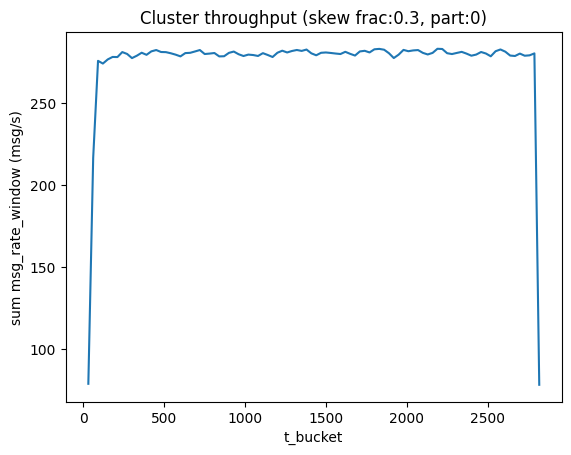

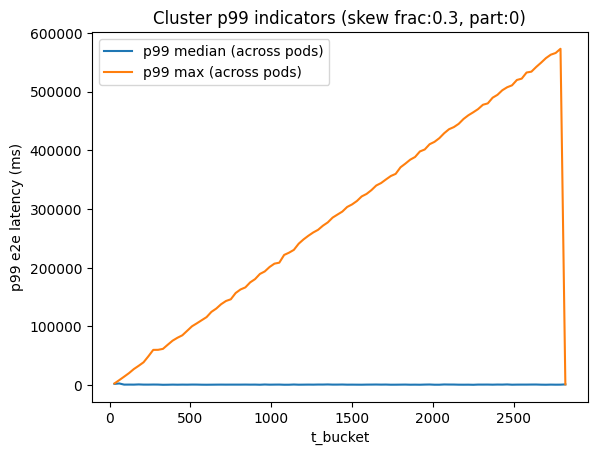

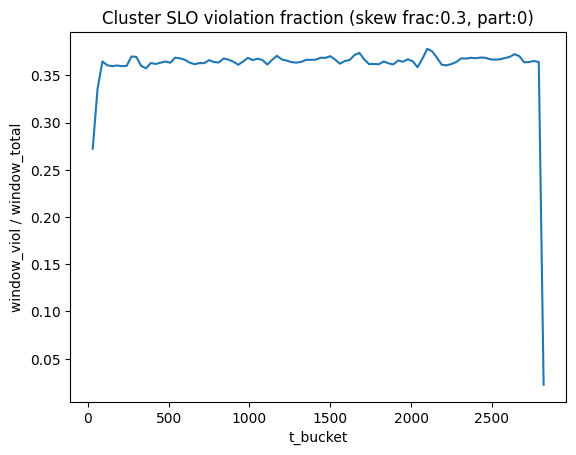

Saved ./analysis_out/20260223_232437_skew/per_pod_merged_20260223_232437_skew.csv and ./analysis_out/cluster_agg_20260223_232437_skew.csv


In [51]:
directory_path = Path(f"analysis_out/{run_id}")
directory_path.mkdir(parents=True, exist_ok=True)

#os.mkdir(f"analysis_out/{run_id}")

# WARMUP_SEC = 90
# cluster["t_bucket_warm"] = cluster["t_bucket"]
# cluster["viol_rate_warm"] = np.where(
#     cluster["t_bucket_warm"] > 90,
#     cluster["viol_rate_warm"] > 0,
#     np.nan
# )
# plt.figure()
# plt.plot(cluster["t_bucket_warm"], cluster["viol_rate_warm"])
# plt.axvline(WARMUP_SEC, linestyle="--")
# plt.title("Cluster SLO violation fraction (with warm-up boundary)")
# plt.xlabel("t_bucket (sec)")
# plt.ylabel("window_viol / window_total")
# plt.savefig(f"analysis_out/{run_id}/SLO violation (with warm-up boundary)_{run_id}.pdf", bbox_inches="tight")
# plt.grid(True)
# plt.show()

# warmup_end = 90
# plt.axvspan(0, warmup_end, alpha=0.2, label="warm-up (ignored)")


# 4) plots
plt.figure()
plt.plot(cluster["t_bucket"], cluster["throughput"])
plt.xlabel("t_bucket")
plt.ylabel("sum msg_rate_window (msg/s)")
plt.title("Cluster throughput (skew frac:0.3, part:0)")
#plt.savefig(f"analysis_out/{run_id}/throughput_{run_id}.png", dpi=300, bbox_inches="tight")
plt.savefig(f"analysis_out/{run_id}/throughput_{run_id}.pdf", bbox_inches="tight")

plt.show()

plt.figure()
plt.plot(cluster["t_bucket"], cluster["p99_med"], label="p99 median (across pods)")
plt.plot(cluster["t_bucket"], cluster["p99_max"], label="p99 max (across pods)")
plt.xlabel("t_bucket")
plt.ylabel("p99 e2e latency (ms)")
plt.title("Cluster p99 indicators (skew frac:0.3, part:0)")
plt.legend()
plt.savefig(f"analysis_out/{run_id}/p99 indicators_{run_id}.pdf", bbox_inches="tight")
plt.show()

plt.figure()
plt.plot(cluster["t_bucket"], cluster["viol_rate"])
plt.xlabel("t_bucket")
plt.ylabel("window_viol / window_total")
plt.title("Cluster SLO violation fraction (skew frac:0.3, part:0)")
plt.savefig(f"analysis_out/{run_id}/SLO violation_{run_id}.pdf", bbox_inches="tight")

plt.show()


# 5) save merged outputs
os.makedirs("./analysis_out", exist_ok=True)
data.to_csv(f"./analysis_out/{run_id}/per_pod_merged_{run_id}.csv", index=False)
cluster.to_csv(f"./analysis_out/{run_id}/cluster_agg_{run_id}.csv", index=False)
print(f"Saved ./analysis_out/{run_id}/per_pod_merged_{run_id}.csv and ./analysis_out/cluster_agg_{run_id}.csv")
